## Part 2: Modeling and Evaluation

This notebook loads the preprocessed feature tensors and DINS-only ground truth labels saved by the preprocessing notebook, then trains and evaluates the Random Forest baseline and U-Net segmentation model using spatial K-fold cross-validation across the combined Palisades + Eaton dataset.

### Environment Setup

In [37]:
# COLAB DRIVE MOUNT
# Uncomment if running in Google Colab.
#from google.colab import drive
#drive.mount("/content/drive")
#import os
#os.chdir("/content/drive/MyDrive/Colab Notebooks/wui_fires")

In [38]:
#!pip install odc-stac contextily rioxarray planetary-computer pystac-client tensorflow

In [ ]:
# CORE LIBRARIES
import json
import warnings
import numpy as np
import matplotlib.pyplot as plt
import rioxarray
from pathlib import Path
from matplotlib.patches import Patch
from rasterio.errors import NotGeoreferencedWarning

# MACHINE LEARNING LIBRARIES
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, jaccard_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

# DEEP LEARNING LIBRARIES
import tensorflow as tf
from tensorflow.keras import mixed_precision
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Dropout, concatenate,
    Conv2DTranspose, BatchNormalization, Activation
)
from tensorflow.keras.layers import SpatialDropout2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import BinaryFocalCrossentropy
from tensorflow.keras import backend as K
from tensorflow.keras.metrics import BinaryIoU

In [40]:
# DISPLAY AND SUPPRESS WARNINGS
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 300
warnings.filterwarnings("ignore", category = NotGeoreferencedWarning)
warnings.filterwarnings("ignore")

# OUTPUT DIRECTORIES
project_path = Path("eaton_test_files")
project_path.mkdir(parents = True, exist_ok = True)

model_path = Path("eaton_test_files/model")
model_path.mkdir(parents = True, exist_ok = True)

images_path = Path("eaton_test_files/images")
images_path.mkdir(parents = True, exist_ok = True)

# RANDOM SEED
random_seed = 42
np.random.seed(random_seed)
tf.random.set_seed(random_seed)

### Load Preprocessed Data

Load the per-fire feature tensors, ground truth labels, and AOI masks saved by the preprocessing notebook. Reconstruct the `fire_data` dictionary expected by the modeling pipeline.

In [41]:
# LOAD PREPROCESSING METADATA
metadata_path = model_path / "preprocessing_metadata.json"
with open(metadata_path, "r") as f:
    preprocessing_metadata = json.load(f)

channel_names = preprocessing_metadata["channel_names"]
channels = preprocessing_metadata["n_channels"]

print(f"Channels: {channels}")
print(f"Channel Names: {channel_names}")
print(f"Fires: {[f['name'] for f in preprocessing_metadata['fires']]}")

# RECONSTRUCT FIRE DATA DICTIONARY
fire_data = {}

for fire_entry in preprocessing_metadata["fires"]:
    fire_name = fire_entry["name"]

    X_tensor = np.load(model_path / fire_entry["X_tensor_file"])
    y_target = np.load(model_path / fire_entry["y_target_file"])
    aoi_mask = np.load(model_path / fire_entry["aoi_mask_file"])

    fire_data[fire_name] = {
        "name": fire_name,
        "X_tensor": X_tensor,
        "y_target": y_target,
        "aoi_mask": aoi_mask,
        "sentinel_shape": tuple(fire_entry["y_shape"]),
    }

    damaged = np.sum(y_target == 1)
    aoi = np.sum(aoi_mask == 1)
    print(f"{fire_name}: X{X_tensor.shape} | Damaged: {damaged:,} | AOI: {aoi:,} | Damage %: {damaged/aoi*100:.2f}%")

print(f"\nFires loaded: {list(fire_data.keys())}")

Channels: 7
Channel Names: ['dNBR', 'DEM Aspect', 'Building Footprints', 'Pre-Fire NIR', 'Pre-Fire SWIR', 'Post-Fire NIR', 'Post-Fire SWIR']
Fires: ['Palisades', 'Eaton']
Palisades: X(801, 1173, 7) | Damaged: 10,111 | AOI: 243,261 | Damage %: 4.16%
Eaton: X(465, 778, 7) | Damaged: 12,287 | AOI: 142,110 | Damage %: 8.65%

Fires loaded: ['Palisades', 'Eaton']


### Spatial K-Fold Cross-Validation (Multi-Fire)

Spatial blocks computed independently per fire with globally unique IDs. Stratified assignment ensures damage blocks are evenly distributed across folds.

In [42]:
# BLOCK PARAMETERS
block_size = 64
patch_size = 64
n_folds = 5

channel_names = [
    "dNBR", "DEM Aspect", "Building Footprints",
    "Pre-Fire NIR", "Pre-Fire SWIR", "Post-Fire NIR", "Post-Fire SWIR",
]

# COMPUTE BLOCK ASSIGNMENTS
fire_block_data = {}
block_id_offset = 0

for fire_name, data in fire_data.items():
    height, width = data["X_tensor"].shape[:2]
    n_blocks_y = int(np.ceil(height / block_size))
    n_blocks_x = int(np.ceil(width / block_size))
    y_indices, x_indices = np.meshgrid(np.arange(height), np.arange(width), indexing = "ij")
    block_y = y_indices // block_size
    block_x = x_indices // block_size
    block_ids = block_y * n_blocks_x + block_x + block_id_offset

    fire_block_data[fire_name] = {
        "block_ids": block_ids,
        "n_blocks_y": n_blocks_y,
        "n_blocks_x": n_blocks_x,
        "block_offset": block_id_offset,
    }
    print(f"{fire_name}: {n_blocks_y}x{n_blocks_x} blocks, IDs [{block_id_offset}, {block_id_offset + n_blocks_y * n_blocks_x - 1}]")
    block_id_offset += n_blocks_y * n_blocks_x

print(f"Total Unique Blocks: {block_id_offset}")


Palisades: 13x19 blocks, IDs [0, 246]
Eaton: 8x13 blocks, IDs [247, 350]
Total Unique Blocks: 351


In [43]:
# STRATIFIED K-FOLD ASSIGNMENT
all_block_ids = []
block_damage_counts = {}

for fire_name, data in fire_data.items():
    block_ids = fire_block_data[fire_name]["block_ids"]
    y_target = data["y_target"]
    aoi_mask = data["aoi_mask"]
    for bid in np.unique(block_ids):
        block_mask = block_ids == bid
        damaged_in_block = np.sum((y_target[block_mask] == 1) & (aoi_mask[block_mask] == 1))
        block_damage_counts[bid] = damaged_in_block
    all_block_ids.extend(np.unique(block_ids))

all_blocks = sorted(all_block_ids)
block_has_damage = np.array([1 if block_damage_counts[b] > 0 else 0 for b in all_blocks])

skf = StratifiedKFold(n_splits = n_folds, shuffle = True, random_state = random_seed)
block_to_fold = {}
fold_blocks = {fold: [] for fold in range(n_folds)}

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(all_blocks, block_has_damage)):
    for idx in test_idx:
        block_id = all_blocks[idx]
        block_to_fold[block_id] = fold_idx
        fold_blocks[fold_idx].append(block_id)

blocks_with_damage = sum(1 for b in all_blocks if block_damage_counts[b] > 0)
print(f"Blocks with Damage: {blocks_with_damage}")
print(f"Blocks without Damage: {len(all_blocks) - blocks_with_damage}")
print()

for fold in range(n_folds):
    fd = sum(1 for b in fold_blocks[fold] if block_damage_counts[b] > 0)
    fp = sum(block_damage_counts[b] for b in fold_blocks[fold])
    print(f"Fold {fold + 1}: {len(fold_blocks[fold])} blocks, {fd} with damage, {fp:,} damage pixels")

Blocks with Damage: 86
Blocks without Damage: 265

Fold 1: 71 blocks, 18 with damage, 2,692 damage pixels
Fold 2: 70 blocks, 17 with damage, 2,279 damage pixels
Fold 3: 70 blocks, 17 with damage, 5,740 damage pixels
Fold 4: 70 blocks, 17 with damage, 3,965 damage pixels
Fold 5: 70 blocks, 17 with damage, 6,805 damage pixels


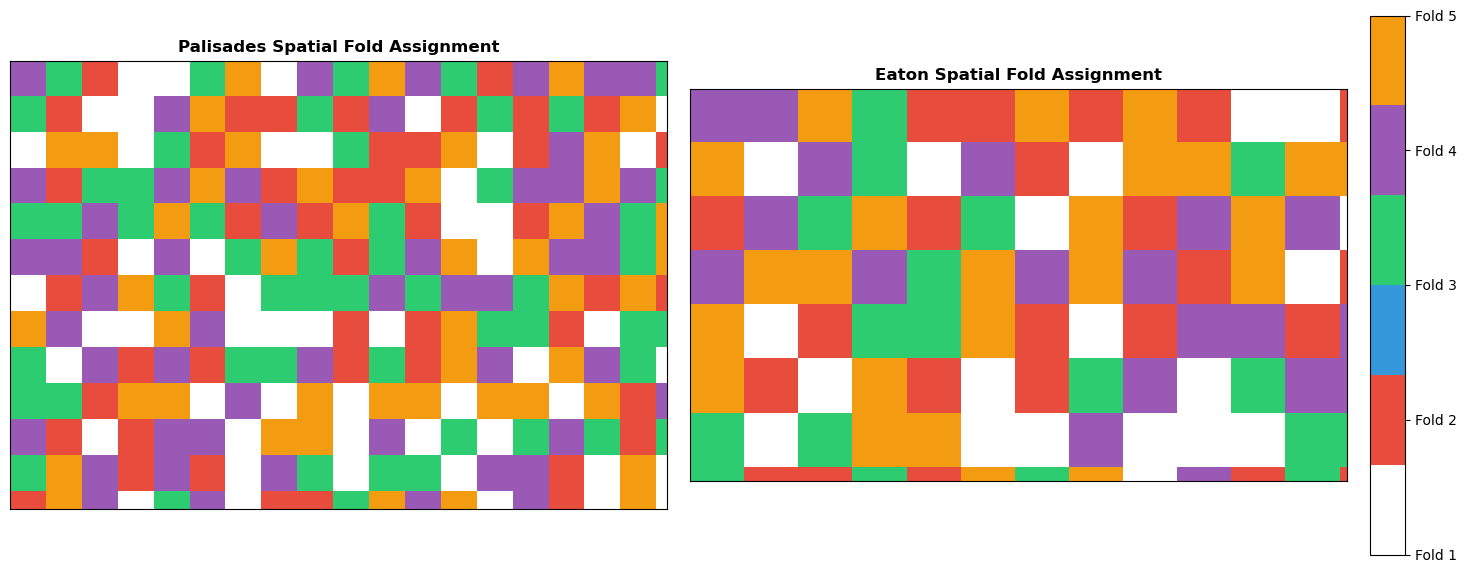

In [44]:
# VISUALIZE FOLD ASSIGNMENTS PER FIRE
fig = plt.figure(figsize = (18, 7))
gs = fig.add_gridspec(1, 3, width_ratios = [1.5, 1.5, 0.08], wspace = 0.05)
axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]

cmap_folds = plt.cm.colors.ListedColormap(["white", "#E74C3C", "#3498DB", "#2ECC71", "#9B59B6", "#F39C12"])

im = None
for idx, fire_name in enumerate(["Palisades", "Eaton"]):
    data = fire_data[fire_name]
    block_ids = fire_block_data[fire_name]["block_ids"]
    height, width = data["X_tensor"].shape[:2]
    fold_vis = np.zeros((height, width), dtype = np.uint8)
    for bid, fold in block_to_fold.items():
        fold_vis[block_ids == bid] = fold + 1

    im = axes[idx].imshow(fold_vis, cmap = cmap_folds, interpolation = "nearest")
    axes[idx].set_title(f"{fire_name} Spatial Fold Assignment", fontweight = "bold")
    axes[idx].xaxis.set_visible(False)
    axes[idx].yaxis.set_visible(False)

cax = fig.add_subplot(gs[0, 2])
cbar = fig.colorbar(im, cax = cax, ticks = range(n_folds + 1))
cbar.set_ticklabels(["Outside"] + [f"Fold {i+1}" for i in range(n_folds)])

plt.savefig(images_path / "fold_assignments.png", dpi = 300, bbox_inches = "tight")
plt.show()

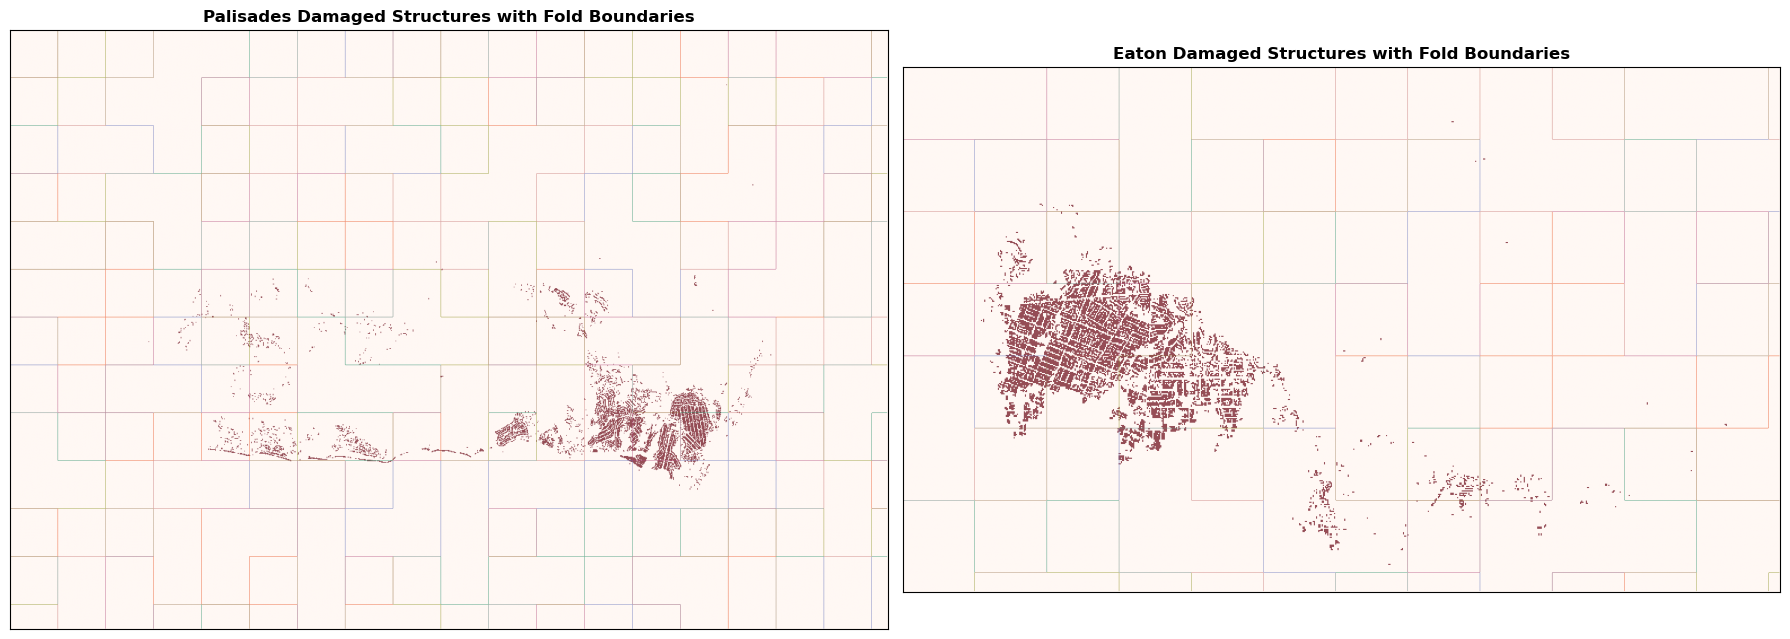

In [45]:
# DAMAGED STRUCTURES WITH FOLD BOUNDARIES PER FIRE
fig, axes = plt.subplots(1, 2, figsize = (18, 7))

for idx, fire_name in enumerate(["Palisades", "Eaton"]):
    data = fire_data[fire_name]
    block_ids = fire_block_data[fire_name]["block_ids"]
    height, width = data["X_tensor"].shape[:2]

    fold_vis = np.zeros((height, width), dtype = np.uint8)
    for bid, fold in block_to_fold.items():
        fold_vis[block_ids == bid] = fold + 1

    axes[idx].imshow(data["y_target"], cmap = "Reds", alpha = 0.7)
    for fold in range(n_folds):
        axes[idx].contour(fold_vis == fold + 1, colors = [plt.cm.tab10(fold)], linewidths = 0.3, alpha = 0.5)
    axes[idx].set_title(f"{fire_name} Damaged Structures with Fold Boundaries", fontsize = 12, fontweight = "bold")
    axes[idx].xaxis.set_visible(False)
    axes[idx].yaxis.set_visible(False)

plt.tight_layout()
plt.savefig(images_path / "damaged_with_folds.png", dpi = 300, bbox_inches = "tight")
plt.show()

In [46]:
def extract_fold_patches_multifire(fire_data, fire_block_data, block_to_fold,
                                   test_fold, patch_size, n_folds):
    """Extract spatially aligned patches from all fires combined."""
    val_fold = (test_fold - 1) % n_folds
    n_channels = list(fire_data.values())[0]["X_tensor"].shape[2]

    train_X, train_y = [], []
    val_X, val_y = [], []
    test_X, test_y = [], []
    train_damage_counts = []

    for fire_name, data in fire_data.items():
        X_tensor = data["X_tensor"]
        y_target = data["y_target"]
        aoi_mask = data["aoi_mask"]
        block_ids = fire_block_data[fire_name]["block_ids"]
        height, width = X_tensor.shape[:2]

        for row in range(0, height - patch_size + 1, patch_size):
            for col in range(0, width - patch_size + 1, patch_size):
                mask_patch = aoi_mask[row:row + patch_size, col:col + patch_size]
                if np.mean(mask_patch) < 0.10:
                    continue

                X_patch = X_tensor[row:row + patch_size, col:col + patch_size, :]
                y_patch = y_target[row:row + patch_size, col:col + patch_size]

                center_r = row + patch_size // 2
                center_c = col + patch_size // 2
                bid = block_ids[center_r, center_c]

                if bid not in block_to_fold:
                    continue

                fold = block_to_fold[bid]
                damage_count = np.sum(y_patch == 1)

                if fold == test_fold:
                    test_X.append(X_patch)
                    test_y.append(y_patch)
                elif fold == val_fold:
                    val_X.append(X_patch)
                    val_y.append(y_patch)
                else:
                    train_X.append(X_patch)
                    train_y.append(y_patch)
                    train_damage_counts.append(damage_count)

    # Oversampling.
    oversampled_X, oversampled_y = [], []
    for i, dc in enumerate(train_damage_counts):
        if dc > 0:
            for _ in range(2):
                oversampled_X.append(train_X[i])
                oversampled_y.append(train_y[i])
    train_X.extend(oversampled_X)
    train_y.extend(oversampled_y)

    empty_X = np.empty((0, patch_size, patch_size, n_channels))
    empty_y = np.empty((0, patch_size, patch_size, 1))

    X_train = np.nan_to_num(np.array(train_X), nan = 0.0) if train_X else empty_X
    y_train = np.array(train_y)[..., np.newaxis] if train_y else empty_y
    X_val = np.nan_to_num(np.array(val_X), nan = 0.0) if val_X else empty_X
    y_val = np.array(val_y)[..., np.newaxis] if val_y else empty_y
    X_test = np.nan_to_num(np.array(test_X), nan = 0.0) if test_X else empty_X
    y_test = np.array(test_y)[..., np.newaxis] if test_y else empty_y

    return X_train, y_train, X_val, y_val, X_test, y_test

In [47]:
# VERIFY PATCH EXTRACTION (FOLD 0)
X_train, y_train, X_val, y_val, X_test, y_test = extract_fold_patches_multifire(
    fire_data, fire_block_data, block_to_fold,
    test_fold = 0, patch_size = patch_size, n_folds = n_folds,
)

print("PATCH EXTRACTION VERIFICATION (FOLD 0 AS TEST)")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")
print(f"Training patches with damage: {np.sum(np.any(y_train[..., 0] == 1, axis = (1, 2)))}")

assert X_train.shape[1:3] == (64, 64)
assert y_train.shape[-1] == 1
print("PASS: All assertions verified.")

PATCH EXTRACTION VERIFICATION (FOLD 0 AS TEST)
X_train: (174, 64, 64, 7), y_train: (174, 64, 64, 1)
X_val:   (23, 64, 64, 7), y_val:   (23, 64, 64, 1)
X_test:  (24, 64, 64, 7), y_test:  (24, 64, 64, 1)
Training patches with damage: 147
PASS: All assertions verified.


In [48]:
# FOLD BALANCE VERIFICATION
print(f"{'Fold':<6} {'Train Patches':>14} {'Val Patches':>12} {'Test Patches':>13} {'Train Dmg Px':>13} {'Test Dmg Px':>12}")
for test_fold in range(n_folds):
    X_tr, y_tr, X_v, y_v, X_te, y_te = extract_fold_patches_multifire(
        fire_data, fire_block_data, block_to_fold, test_fold, patch_size, n_folds,
    )
    print(f"  {test_fold+1:<4} {X_tr.shape[0]:>14} {X_v.shape[0]:>12} {X_te.shape[0]:>13} {np.sum(y_tr[...,0]==1):>13,} {np.sum(y_te[...,0]==1):>12,}")

Fold    Train Patches  Val Patches  Test Patches  Train Dmg Px  Test Dmg Px
  1               174           23            24        36,720        2,742
  2               170           24            27        50,499        2,342
  3               158           27            26        41,109        5,872
  4               160           26            23        36,057        4,026
  5               169           23            23        32,868        6,935


## Baseline Model: Random Forest with Spatial K-Fold CV

In [49]:
# RANDOM FOREST K-FOLD CROSS-VALIDATION
rf_fold_results = {
    "f1_train": [], "f1_val": [], "f1_test": [],
    "iou_train": [], "iou_val": [], "iou_test": [],
    "feature_importance": [],
}

for fold in range(n_folds):
    print(f"FOLD {fold + 1}/{n_folds}")

    X_train, y_train, X_val, y_val, X_test, y_test = extract_fold_patches_multifire(
        fire_data, fire_block_data, block_to_fold, fold, patch_size, n_folds,
    )

    X_train_rf = X_train.reshape(-1, channels)
    y_train_rf = y_train.reshape(-1)
    X_val_rf = X_val.reshape(-1, channels)
    y_val_rf = y_val.reshape(-1)
    X_test_rf = X_test.reshape(-1, channels)
    y_test_rf = y_test.reshape(-1)

    print(f"Train: {X_train_rf.shape[0]:,} px | Val: {X_val_rf.shape[0]:,} | Test: {X_test_rf.shape[0]:,}")

    rf_classifier = RandomForestClassifier(
        n_estimators = 100, max_depth = 15, min_samples_split = 5,
        min_samples_leaf = 2, class_weight = "balanced",
        random_state = random_seed, n_jobs = -1, verbose = 0,
    )
    rf_classifier.fit(X_train_rf, y_train_rf)

    y_pred_train = rf_classifier.predict(X_train_rf)
    y_pred_val = rf_classifier.predict(X_val_rf)
    y_pred_test = rf_classifier.predict(X_test_rf)

    f1_train = f1_score(y_train_rf, y_pred_train, average = "binary", zero_division = 0)
    f1_val = f1_score(y_val_rf, y_pred_val, average = "binary", zero_division = 0)
    f1_test = f1_score(y_test_rf, y_pred_test, average = "binary", zero_division = 0)
    iou_train = jaccard_score(y_train_rf, y_pred_train, average = "binary", zero_division = 0)
    iou_val = jaccard_score(y_val_rf, y_pred_val, average = "binary", zero_division = 0)
    iou_test = jaccard_score(y_test_rf, y_pred_test, average = "binary", zero_division = 0)

    rf_fold_results["f1_train"].append(f1_train)
    rf_fold_results["f1_val"].append(f1_val)
    rf_fold_results["f1_test"].append(f1_test)
    rf_fold_results["iou_train"].append(iou_train)
    rf_fold_results["iou_val"].append(iou_val)
    rf_fold_results["iou_test"].append(iou_test)
    rf_fold_results["feature_importance"].append(rf_classifier.feature_importances_)

    print(f"Test F1: {f1_test:.4f} | Test IoU: {iou_test:.4f}")

FOLD 1/5
Train: 712,704 px | Val: 94,208 | Test: 98,304
Test F1: 0.4151 | Test IoU: 0.2619
FOLD 2/5
Train: 696,320 px | Val: 98,304 | Test: 110,592
Test F1: 0.2688 | Test IoU: 0.1553
FOLD 3/5
Train: 647,168 px | Val: 110,592 | Test: 106,496
Test F1: 0.4195 | Test IoU: 0.2654
FOLD 4/5
Train: 655,360 px | Val: 106,496 | Test: 94,208
Test F1: 0.4251 | Test IoU: 0.2699
FOLD 5/5
Train: 692,224 px | Val: 94,208 | Test: 94,208
Test F1: 0.5219 | Test IoU: 0.3531


RANDOM FOREST TEST METRICS (mean +/- std)
  F1 Score: 0.4101 +/- 0.0810
  IoU:      0.2611 +/- 0.0629


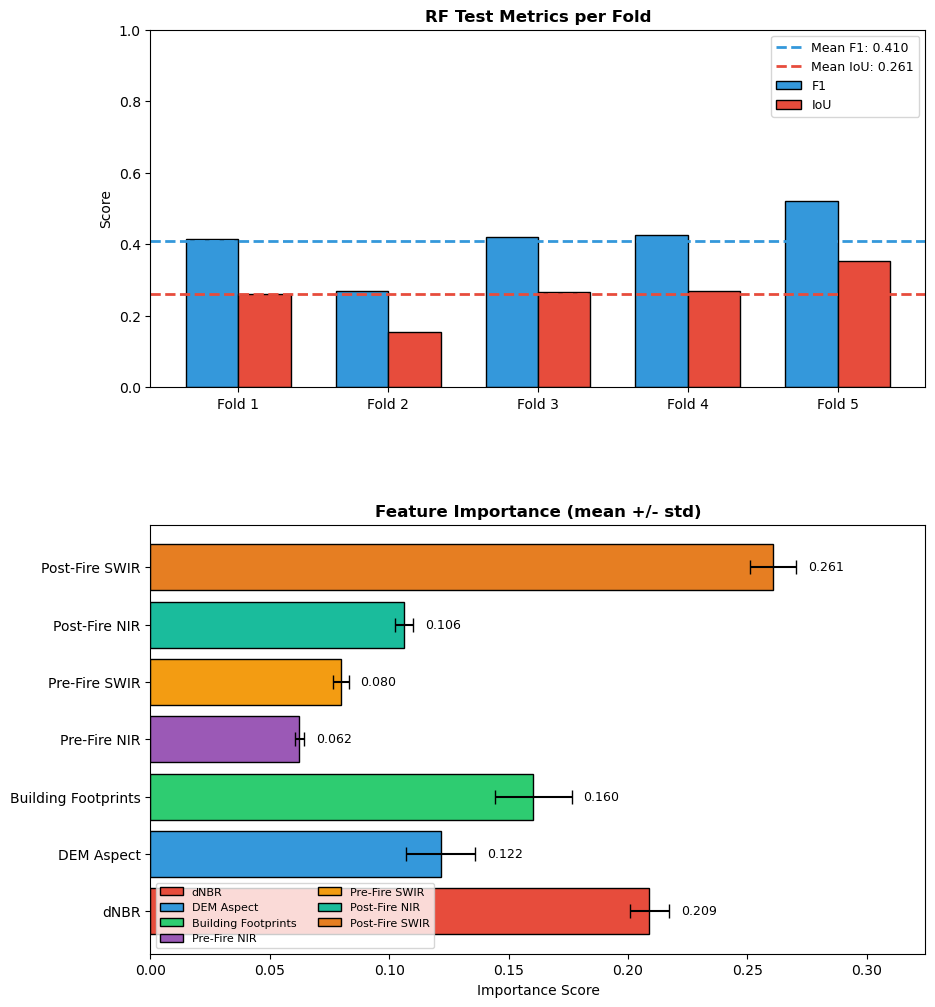

In [50]:
# AGGREGATE AND VISUALIZE RANDOM FOREST RESULTS
rf_f1_mean = np.mean(rf_fold_results["f1_test"])
rf_f1_std = np.std(rf_fold_results["f1_test"])
rf_iou_mean = np.mean(rf_fold_results["iou_test"])
rf_iou_std = np.std(rf_fold_results["iou_test"])
rf_fi_mean = np.mean(rf_fold_results["feature_importance"], axis = 0)
rf_fi_std = np.std(rf_fold_results["feature_importance"], axis = 0)

print("RANDOM FOREST TEST METRICS (mean +/- std)")
print(f"  F1 Score: {rf_f1_mean:.4f} +/- {rf_f1_std:.4f}")
print(f"  IoU:      {rf_iou_mean:.4f} +/- {rf_iou_std:.4f}")

fig = plt.figure(figsize = (10, 12))
gs = fig.add_gridspec(2, 1, height_ratios = [1, 1.2], hspace = 0.35)
axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[1, 0])]

# Per-fold metrics.
x_pos = np.arange(n_folds)
w = 0.35
axes[0].bar(x_pos - w/2, rf_fold_results["f1_test"], w, label = "F1", color = "#3498DB", edgecolor = "black")
axes[0].bar(x_pos + w/2, rf_fold_results["iou_test"], w, label = "IoU", color = "#E74C3C", edgecolor = "black")
axes[0].axhline(y = rf_f1_mean, color = "#3498DB", linestyle = "--", lw = 2, label = f"Mean F1: {rf_f1_mean:.3f}")
axes[0].axhline(y = rf_iou_mean, color = "#E74C3C", linestyle = "--", lw = 2, label = f"Mean IoU: {rf_iou_mean:.3f}")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([f"Fold {i+1}" for i in range(n_folds)])
axes[0].set_ylabel("Score")
axes[0].set_title("RF Test Metrics per Fold", fontweight = "bold")
axes[0].legend(loc = "upper right", fontsize = 9)
axes[0].set_ylim(0, 1)

# Feature importance.
colors = ["#E74C3C", "#3498DB", "#2ECC71", "#9B59B6", "#F39C12", "#1ABC9C", "#E67E22", "#34495E"]
bars = axes[1].barh(channel_names, rf_fi_mean, xerr = rf_fi_std, color = colors, edgecolor = "black", capsize = 5)
axes[1].set_xlabel("Importance Score")
axes[1].set_title("Feature Importance (mean +/- std)", fontweight = "bold")
for idx_fi, (m, s) in enumerate(zip(rf_fi_mean, rf_fi_std)):
    axes[1].text(m + s + 0.005, idx_fi, f"{m:.3f}", va = "center", fontsize = 9)

# Add legend for colors
legend_elements = [Patch(facecolor = colors[i], edgecolor = "black", label = channel_names[i]) for i in range(len(channel_names))]
axes[1].legend(handles = legend_elements, loc = "lower left", fontsize = 8, ncol = 2)

# Set explicit x-axis limit with margin for error bars and text
axes[1].set_xlim(0, max(rf_fi_mean + rf_fi_std) * 1.2)

plt.savefig(images_path / "rf_fold_metrics.png", dpi = 300, bbox_inches = "tight")
plt.show()

## Primary Model: Topographically Aware U-Net

In [51]:
# Enable mixed precision globally before any model is constructed.
mixed_precision.set_global_policy("mixed_float16")

In [52]:
# LOSS FUNCTIONS AND METRICS
def dice_loss(y_true, y_pred, smooth = 1e-6):
    # Flatten tensors to compute overlap across all spatial positions.
    y_true_flat = K.flatten(K.cast(y_true, "float32"))
    y_pred_flat = K.flatten(y_pred)
    intersection = K.sum(y_true_flat * y_pred_flat)
    union = K.sum(y_true_flat) + K.sum(y_pred_flat)
    # Return the Dice loss, where 1.0 is worst and 0.0 is perfect overlap.
    return 1.0 - (2.0 * intersection + smooth) / (union + smooth)

# Alpha of 0.80 heavily weights the minority damaged class at ~5.8% prevalence.
# Gamma of 3.0 more aggressively down-weights easy negatives than the default of 2.0.
focal_loss_fn = BinaryFocalCrossentropy(
    apply_class_balancing = True, alpha = 0.80, gamma = 3.0, from_logits = False,
)

def combined_loss(y_true, y_pred, dice_weight = 0.5, focal_weight = 0.5):
    # Combine Dice and Focal losses with equal weighting.
    return dice_weight * dice_loss(y_true, y_pred) + focal_weight * focal_loss_fn(y_true, y_pred)

def dice_coef_metric(y_true, y_pred, smooth = 1e-6):
    # Compute the Dice coefficient as a training-time monitoring metric.
    y_true_flat = K.flatten(K.cast(y_true, "float32"))
    y_pred_flat = K.flatten(y_pred)
    intersection = K.sum(y_true_flat * y_pred_flat)
    union = K.sum(y_true_flat) + K.sum(y_pred_flat)
    return (2.0 * intersection + smooth) / (union + smooth)

def find_optimal_threshold(y_true_flat, y_pred_proba_flat):
    # Sweep candidate thresholds and select the one maximizing binary F1.
    thresholds = np.linspace(0.1, 0.7, 61)
    f1_scores = [
        f1_score(
            y_true_flat,
            (y_pred_proba_flat > t).astype(np.uint8),
            average = "binary",
            zero_division = 0,
        )
        for t in thresholds
    ]
    optimal_threshold = thresholds[np.argmax(f1_scores)]
    return optimal_threshold, float(max(f1_scores))

In [53]:
# U-NET ARCHITECTURE
def conv_block(inputs, filters, kernel_size = 3, dropout_rate = 0.1, spatial_dropout_rate = 0.1):
    # Apply two sequential convolutions with batch normalization and ReLU activation.
    x = Conv2D(filters, kernel_size, padding = "same", kernel_initializer = "he_normal")(inputs)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Conv2D(filters, kernel_size, padding = "same", kernel_initializer = "he_normal")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    # Apply standard dropout to individual activations.
    if dropout_rate > 0:
        x = Dropout(dropout_rate)(x)
    # Apply spatial dropout to entire feature maps for stronger regularization.
    if spatial_dropout_rate > 0:
        x = SpatialDropout2D(spatial_dropout_rate)(x)
    return x

def build_unet_64(input_shape = (64, 64, 7), num_classes = 1, base_filters = 32):
    inputs = Input(shape = input_shape)

    # ENCODER PATH
    enc1 = conv_block(inputs, base_filters, dropout_rate = 0.1, spatial_dropout_rate = 0.1)
    pool1 = MaxPooling2D(pool_size = (2, 2))(enc1)
    enc2 = conv_block(pool1, base_filters * 2, dropout_rate = 0.1, spatial_dropout_rate = 0.1)
    pool2 = MaxPooling2D(pool_size = (2, 2))(enc2)
    enc3 = conv_block(pool2, base_filters * 4, dropout_rate = 0.2, spatial_dropout_rate = 0.15)
    pool3 = MaxPooling2D(pool_size = (2, 2))(enc3)

    # BOTTLENECK
    bottleneck = conv_block(pool3, base_filters * 8, dropout_rate = 0.3, spatial_dropout_rate = 0.2)

    # DECODER PATH
    up3 = Conv2DTranspose(base_filters * 4, (2, 2), strides = (2, 2), padding = "same")(bottleneck)
    up3 = concatenate([up3, enc3])
    dec3 = conv_block(up3, base_filters * 4, dropout_rate = 0.2, spatial_dropout_rate = 0.15)
    up2 = Conv2DTranspose(base_filters * 2, (2, 2), strides = (2, 2), padding = "same")(dec3)
    up2 = concatenate([up2, enc2])
    dec2 = conv_block(up2, base_filters * 2, dropout_rate = 0.1, spatial_dropout_rate = 0.1)
    up1 = Conv2DTranspose(base_filters, (2, 2), strides = (2, 2), padding = "same")(dec2)
    up1 = concatenate([up1, enc1])
    dec1 = conv_block(up1, base_filters, dropout_rate = 0.1, spatial_dropout_rate = 0.1)

    # OUTPUT HEAD — cast to float32 required under mixed precision.
    outputs = Conv2D(num_classes, (1, 1), activation = "linear")(dec1)
    outputs = Activation("sigmoid", dtype = "float32", name = "sigmoid_float32")(outputs)
    return Model(inputs = inputs, outputs = outputs, name = "TopographicallyAwareUNet_64")

# VERIFY ARCHITECTURE
test_model = build_unet_64(input_shape = (64, 64, channels))
test_model.summary()
del test_model

Model: "TopographicallyAwareUNet_64"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 64, 64, 7) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 64, 64,    │      2,048 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 64, 64,    │      9,248 │ activation_14[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 64, 64,    │          0 │ activation_15[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_7 │ (None, 64, 64,    │          0 │ dropout_7[0][0]   │
│ (SpatialDropout2D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 32, 32,    │          0 │ spatial_dropout2… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 32, 32,    │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 32, 32,    │     36,928 │ activation_16[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_17       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 32, 32,    │          0 │ activation_17[0]

 Total params: 1,932,385 (7.37 MB)

 Trainable params: 1,929,569 (7.36 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [54]:
# AUGMENTATION FUNCTION
def augment(x, y):
    # Apply a random left-right flip identically to the patch and its label mask.
    flip_lr = tf.random.uniform([], 0, 1.0, dtype = tf.float32) > 0.5
    x = tf.cond(flip_lr, lambda: tf.image.flip_left_right(x), lambda: x)
    y = tf.cond(flip_lr, lambda: tf.image.flip_left_right(y), lambda: y)

    # Apply a random up-down flip identically to the patch and its label mask.
    flip_ud = tf.random.uniform([], 0, 1.0, dtype = tf.float32) > 0.5
    x = tf.cond(flip_ud, lambda: tf.image.flip_up_down(x), lambda: x)
    y = tf.cond(flip_ud, lambda: tf.image.flip_up_down(y), lambda: y)

    # Apply a random 90-degree rotation (0, 90, 180, or 270 degrees).
    # Nadir satellite imagery has no canonical orientation, so all rotations are valid.
    k = tf.random.uniform([], minval = 0, maxval = 4, dtype = tf.int32)
    x = tf.image.rot90(x, k = k)
    y = tf.image.rot90(y, k = k)

    return x, y

### U-Net K-Fold Cross-Validation

In [55]:
# U-NET K-FOLD TRAINING
unet_fold_results = {
    "f1_test": [],
    "f1_test_tuned": [],
    "iou_test": [],
    "f1_val": [],
    "best_val_dice": [],
    "epochs_trained": [],
    "optimal_threshold": [],
}

best_overall_val_f1 = -1.0

model_file = model_path / "unet_best_model.keras"
metrics_file = model_path / "kfold_metrics_summary.json"

if not model_file.exists() or not metrics_file.exists():
    for fold in range(n_folds):
        print(f"\nFOLD {fold + 1}/{n_folds}")

        X_train, y_train, X_val, y_val, X_test, y_test = extract_fold_patches_multifire(
            fire_data, fire_block_data, block_to_fold, fold, patch_size, n_folds,
        )
        print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

        if X_train.shape[0] == 0 or X_test.shape[0] == 0:
            print("SKIPPED: insufficient data.")
            for key in unet_fold_results:
                unet_fold_results[key].append(float("nan"))
            continue

        # Fit the scaler on training patches only and apply to val and test.
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train.reshape(-1, channels)).reshape(X_train.shape)
        X_val = scaler.transform(X_val.reshape(-1, channels)).reshape(X_val.shape)
        X_test = scaler.transform(X_test.reshape(-1, channels)).reshape(X_test.shape)

        # Build tf.data pipelines, applying augmentation only to the training split.
        batch_size = 16
        train_dataset = (
            tf.data.Dataset.from_tensor_slices((X_train, y_train))
            .shuffle(buffer_size = 1024)
            .map(augment, num_parallel_calls = tf.data.AUTOTUNE)
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE)
        )
        val_dataset = (
            tf.data.Dataset.from_tensor_slices((X_val, y_val))
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE)
        )

        tf.keras.backend.clear_session()
        tf.random.set_seed(random_seed)

        fold_iou = BinaryIoU(target_class_ids = [1], threshold = 0.5, name = "iou_metric")
        model = build_unet_64(input_shape = (patch_size, patch_size, channels))

        # Scale learning rate linearly with batch size relative to the original batch of 8.
        scaled_lr = 1e-3 * (batch_size / 8)

        model.compile(
            optimizer = Adam(learning_rate = scaled_lr),
            loss = combined_loss,
            metrics = [dice_coef_metric, fold_iou],
        )

        callbacks = [
            EarlyStopping(
                monitor = "val_loss",
                patience = 10,
                min_delta = 1e-3,
                restore_best_weights = True,
                verbose = 1,
            ),
            ReduceLROnPlateau(
                monitor = "val_loss",
                patience = 5,
                factor = 0.5,
                min_delta = 1e-3,
                min_lr = 1e-6,
                verbose = 1,
            ),
        ]

        history = model.fit(
            train_dataset,
            validation_data = val_dataset,
            epochs = 50,
            callbacks = callbacks,
            verbose = 1,
        )

        # THRESHOLD SELECTION ON VALIDATION SET
        # Threshold is tuned on validation predictions and then applied to the test set.
        y_pred_proba_val = model.predict(X_val, verbose = 0).flatten()
        y_pred_proba_test = model.predict(X_test, verbose = 0).flatten()

        optimal_thresh, val_f1_at_thresh = find_optimal_threshold(y_val.flatten(), y_pred_proba_val)
        print(f"Optimal threshold: {optimal_thresh:.2f} | Val F1 at threshold: {val_f1_at_thresh:.4f}")

        # Fixed threshold evaluation reflects honest generalization performance.
        y_pred_fixed = (y_pred_proba_test > 0.5).astype(np.uint8)
        f1_test = f1_score(y_test.flatten(), y_pred_fixed, average = "binary", zero_division = 0)
        iou_test = jaccard_score(y_test.flatten(), y_pred_fixed, average = "binary", zero_division = 0)

        # Tuned threshold evaluation reflects operational utility at deployment.
        y_pred_tuned = (y_pred_proba_test > optimal_thresh).astype(np.uint8)
        f1_test_tuned = f1_score(y_test.flatten(), y_pred_tuned, average = "binary", zero_division = 0)

        f1_val = f1_score(
            y_val.flatten(),
            (y_pred_proba_val > 0.5).astype(np.uint8),
            average = "binary",
            zero_division = 0,
        )
        best_val_dice = max(history.history.get("val_dice_coef_metric", [0]))
        epochs_trained = len(history.history["loss"])

        unet_fold_results["f1_test"].append(float(f1_test))
        unet_fold_results["f1_test_tuned"].append(float(f1_test_tuned))
        unet_fold_results["iou_test"].append(float(iou_test))
        unet_fold_results["f1_val"].append(float(f1_val))
        unet_fold_results["best_val_dice"].append(float(best_val_dice))
        unet_fold_results["epochs_trained"].append(int(epochs_trained))
        unet_fold_results["optimal_threshold"].append(float(optimal_thresh))

        print(f"Test F1 (0.5): {f1_test:.4f} | Test F1 (tuned): {f1_test_tuned:.4f} | IoU: {iou_test:.4f} | Val Dice: {best_val_dice:.4f} | Epochs: {epochs_trained}")

        # Save the best model across folds based on Validation F1 score.
        if f1_val > best_overall_val_f1:
            best_overall_val_f1 = float(f1_val)
            model.save(model_file)
            print(f"Saved new best model (Val F1: {best_overall_val_f1:.4f})")

    with open(metrics_file, "w") as f:
        json.dump(unet_fold_results, f, indent=4)
    print(f"\nSaved k-fold metrics summary to {metrics_file}")
else:
    print(f"Found existing model at {model_file}. Skipping training.")
    with open(metrics_file, "r") as f:
        unet_fold_results = json.load(f)
    print(f"Loaded existing metrics from {metrics_file}")

Found existing model at eaton_test_files\model\unet_best_model.keras. Skipping training.
Loaded existing metrics from eaton_test_files\model\kfold_metrics_summary.json


U-NET RESULTS (mean +/- std)
F1 Score: 0.6532 +/- 0.0469
IoU: 0.4868 +/- 0.0520


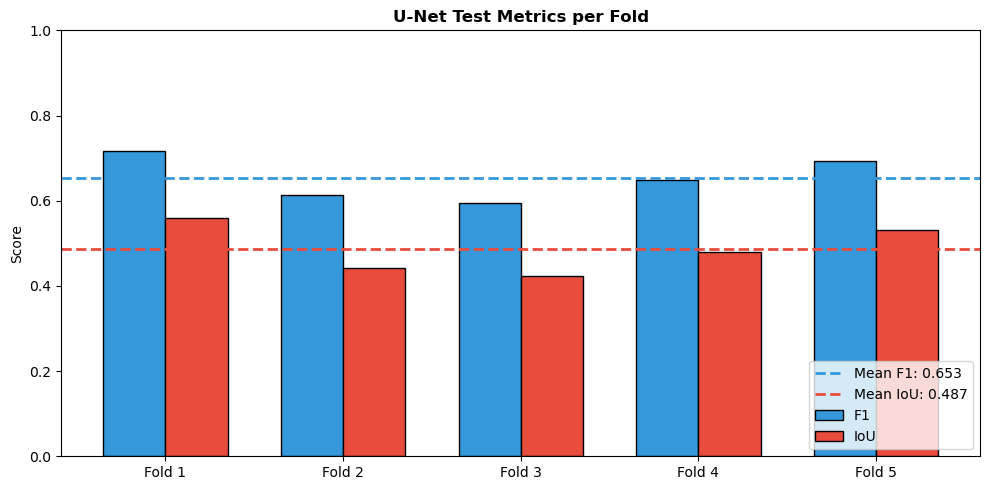

In [56]:
# AGGREGATE AND VISUALIZE U-NET RESULTS
valid_f1 = [x for x in unet_fold_results["f1_test"] if not np.isnan(x)]
valid_iou = [x for x in unet_fold_results["iou_test"] if not np.isnan(x)]

unet_f1_mean = np.mean(valid_f1) if valid_f1 else 0
unet_f1_std = np.std(valid_f1) if valid_f1 else 0
unet_iou_mean = np.mean(valid_iou) if valid_iou else 0
unet_iou_std = np.std(valid_iou) if valid_iou else 0

print("U-NET RESULTS (mean +/- std)")
print(f"F1 Score: {unet_f1_mean:.4f} +/- {unet_f1_std:.4f}")
print(f"IoU: {unet_iou_mean:.4f} +/- {unet_iou_std:.4f}")

fig, ax = plt.subplots(figsize = (10, 5))
x_pos = np.arange(n_folds)
w = 0.35
f1_vals = [x if not np.isnan(x) else 0 for x in unet_fold_results["f1_test"]]
iou_vals = [x if not np.isnan(x) else 0 for x in unet_fold_results["iou_test"]]

ax.bar(x_pos - w/2, f1_vals, w, label = "F1", color = "#3498DB", edgecolor = "black")
ax.bar(x_pos + w/2, iou_vals, w, label = "IoU", color = "#E74C3C", edgecolor = "black")
ax.axhline(y = unet_f1_mean, color = "#3498DB", linestyle = "--", lw = 2, label = f"Mean F1: {unet_f1_mean:.3f}")
ax.axhline(y = unet_iou_mean, color = "#E74C3C", linestyle = "--", lw = 2, label = f"Mean IoU: {unet_iou_mean:.3f}")
ax.set_xticks(x_pos)
ax.set_xticklabels([f"Fold {i+1}" for i in range(n_folds)])
ax.set_ylabel("Score")
ax.set_title("U-Net Test Metrics per Fold", fontweight = "bold")
ax.legend(loc = "lower right")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(images_path / "unet_fold_metrics.png", dpi = 300, bbox_inches = "tight")
plt.show()

## Model Comparison

In [57]:
# MODEL COMPARISON SUMMARY
f1_diff = unet_f1_mean - rf_f1_mean
iou_diff = unet_iou_mean - rf_iou_mean

print("MODEL COMPARISON (5-FOLD SPATIAL CV, PALISADES + EATON)")
print("\nRandom Forest Baseline")
print(f"F1: {rf_f1_mean:.4f} +/- {rf_f1_std:.4f}")
print(f"IoU: {rf_iou_mean:.4f} +/- {rf_iou_std:.4f}")
print("\nU-Net Primary Model")
print(f"F1: {unet_f1_mean:.4f} +/- {unet_f1_std:.4f}")
print(f"IoU: {unet_iou_mean:.4f} +/- {unet_iou_std:.4f}")
print("\nDifference (U-Net - RF)")
print(f"F1: {f1_diff:+.4f}")
print(f"IoU: {iou_diff:+.4f}")

if unet_f1_mean >= 0.70:
    print("\nSTATUS: Operational utility threshold reached (F1 >= 0.70).")
elif unet_f1_mean >= 0.50:
    print("\nSTATUS: Predictive signal confirmed (F1 >= 0.50), below operational utility.")
else:
    print("\nSTATUS: Below predictive signal threshold (F1 < 0.50).")

print("\nRF FEATURE IMPORTANCE")
for idx_fi, name in enumerate(channel_names):
    print(f"{name}: {rf_fi_mean[idx_fi]:.4f} +/- {rf_fi_std[idx_fi]:.4f}")

MODEL COMPARISON (5-FOLD SPATIAL CV, PALISADES + EATON)

Random Forest Baseline
F1: 0.4101 +/- 0.0810
IoU: 0.2611 +/- 0.0629

U-Net Primary Model
F1: 0.6532 +/- 0.0469
IoU: 0.4868 +/- 0.0520

Difference (U-Net - RF)
F1: +0.2431
IoU: +0.2257

STATUS: Predictive signal confirmed (F1 >= 0.50), below operational utility.

RF FEATURE IMPORTANCE
dNBR: 0.2089 +/- 0.0082
DEM Aspect: 0.1215 +/- 0.0144
Building Footprints: 0.1603 +/- 0.0161
Pre-Fire NIR: 0.0624 +/- 0.0020
Pre-Fire SWIR: 0.0797 +/- 0.0032
Post-Fire NIR: 0.1063 +/- 0.0037
Post-Fire SWIR: 0.2609 +/- 0.0096


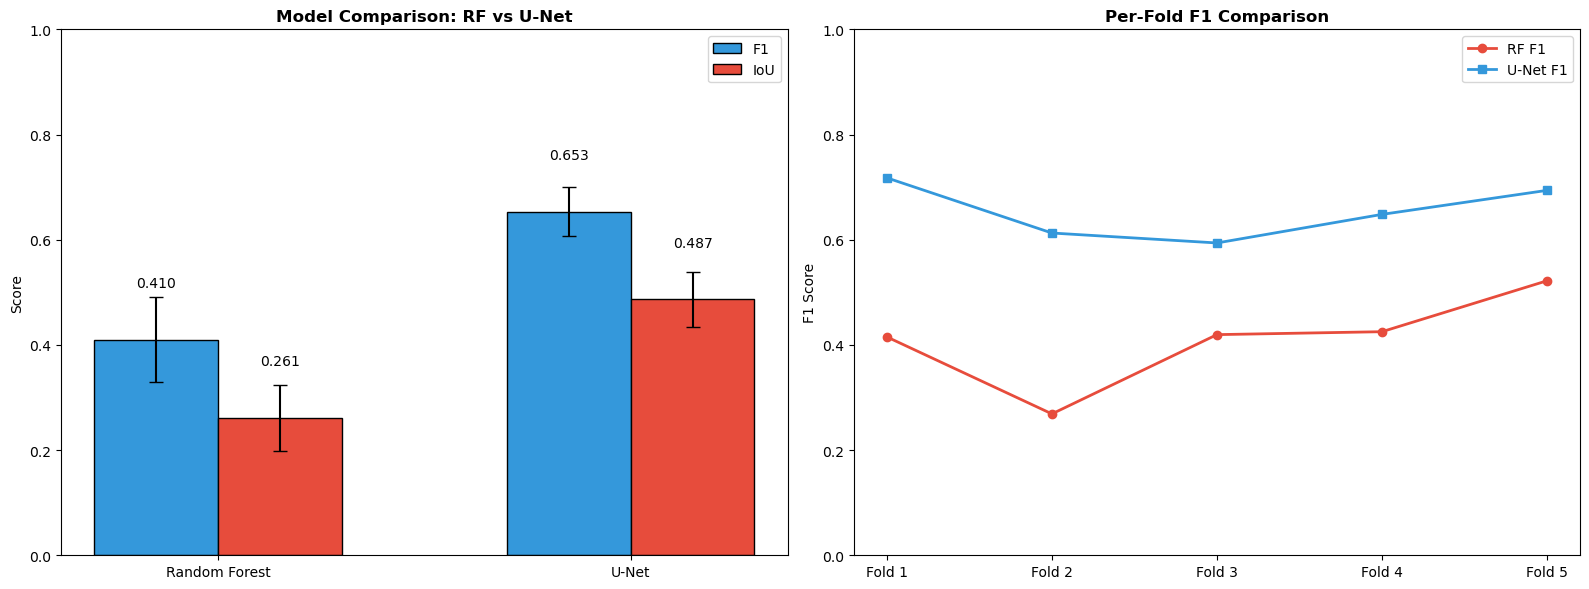

In [58]:
# MODEL COMPARISON BAR CHART
fig, axes = plt.subplots(1, 2, figsize = (16, 6))

# Grouped bar chart.
models = ["Random Forest", "U-Net"]
f1_means = [rf_f1_mean, unet_f1_mean]
f1_stds = [rf_f1_std, unet_f1_std]
iou_means = [rf_iou_mean, unet_iou_mean]
iou_stds = [rf_iou_std, unet_iou_std]

x_pos = np.arange(len(models))
w = 0.3
b1 = axes[0].bar(x_pos - w/2, f1_means, w, yerr = f1_stds, label = "F1", color = "#3498DB", edgecolor = "black", capsize = 5)
b2 = axes[0].bar(x_pos + w/2, iou_means, w, yerr = iou_stds, label = "IoU", color = "#E74C3C", edgecolor = "black", capsize = 5)
for bg in [b1, b2]:
    for bar in bg:
        h = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.1, f"{h:.3f}", ha = "center", fontsize = 10)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models)
axes[0].set_ylabel("Score")
axes[0].set_title("Model Comparison: RF vs U-Net", fontweight = "bold")
axes[0].legend()
axes[0].set_ylim(0, 1)

# Per-fold comparison.
x_pos2 = np.arange(n_folds)
axes[1].plot(x_pos2, rf_fold_results["f1_test"], "o-", label = "RF F1", color = "#E74C3C", lw = 2)
axes[1].plot(x_pos2, unet_fold_results["f1_test"], "s-", label = "U-Net F1", color = "#3498DB", lw = 2)
axes[1].set_xticks(x_pos2)
axes[1].set_xticklabels([f"Fold {i+1}" for i in range(n_folds)])
axes[1].set_ylabel("F1 Score")
axes[1].set_title("Per-Fold F1 Comparison", fontweight = "bold")
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(images_path / "model_comparison.png", dpi = 300, bbox_inches = "tight")
plt.show()

In [59]:
# PER-FOLD DETAIL TABLE
print("PER-FOLD TEST F1 SCORES")
print(f"{'Fold':<8} {'RF F1':>10} {'U-Net F1':>10} {'Diff':>10}")
for fold in range(n_folds):
    rf_f1 = rf_fold_results["f1_test"][fold]
    unet_f1 = unet_fold_results["f1_test"][fold]
    diff = unet_f1 - rf_f1 if not np.isnan(unet_f1) else float("nan")
    print(f"Fold {fold + 1:<3} {rf_f1:>10.4f} {unet_f1:>10.4f} {diff:>+10.4f}")

PER-FOLD TEST F1 SCORES
Fold          RF F1   U-Net F1       Diff
Fold 1       0.4151     0.7176    +0.3024
Fold 2       0.2688     0.6127    +0.3439
Fold 3       0.4195     0.5938    +0.1743
Fold 4       0.4251     0.6481    +0.2231
Fold 5       0.5219     0.6938    +0.1719


### AI Use

Used free model Claude Haiku 4.5 for debugging and assisting with defining functions.